# CMPT 310 — Milestone 1: Data Exploration
This notebook inspects the Kaggle clothing dataset and verifies that our four target labels exist.

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

from src.data_loader import load_metadata, check_available_labels, filter_and_balance

## 1. Load Metadata
Update `CSV_PATH` to point to the CSV file inside `data/raw/` after downloading from Kaggle.

In [2]:
CSV_PATH = '../data/raw/styles.csv'   # update if filename differs
IMG_DIR  = '../data/raw/images'       # update if folder name differs

df = load_metadata(CSV_PATH)
df.head()

Loaded 44424 rows, columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


## 2. Check Available Labels
Per TA feedback: confirm which of the four labels (color, season, type, usage) are actually in the dataset before assuming they exist.

In [3]:
print('Checking available labels:')
available_labels = check_available_labels(df)

Checking available labels:
  [baseColour] found — 46 unique values, 15 missing
  [season] found — 4 unique values, 21 missing
  [articleType] found — 143 unique values, 0 missing
  [usage] found — 8 unique values, 317 missing


## 3. Class Distribution per Label

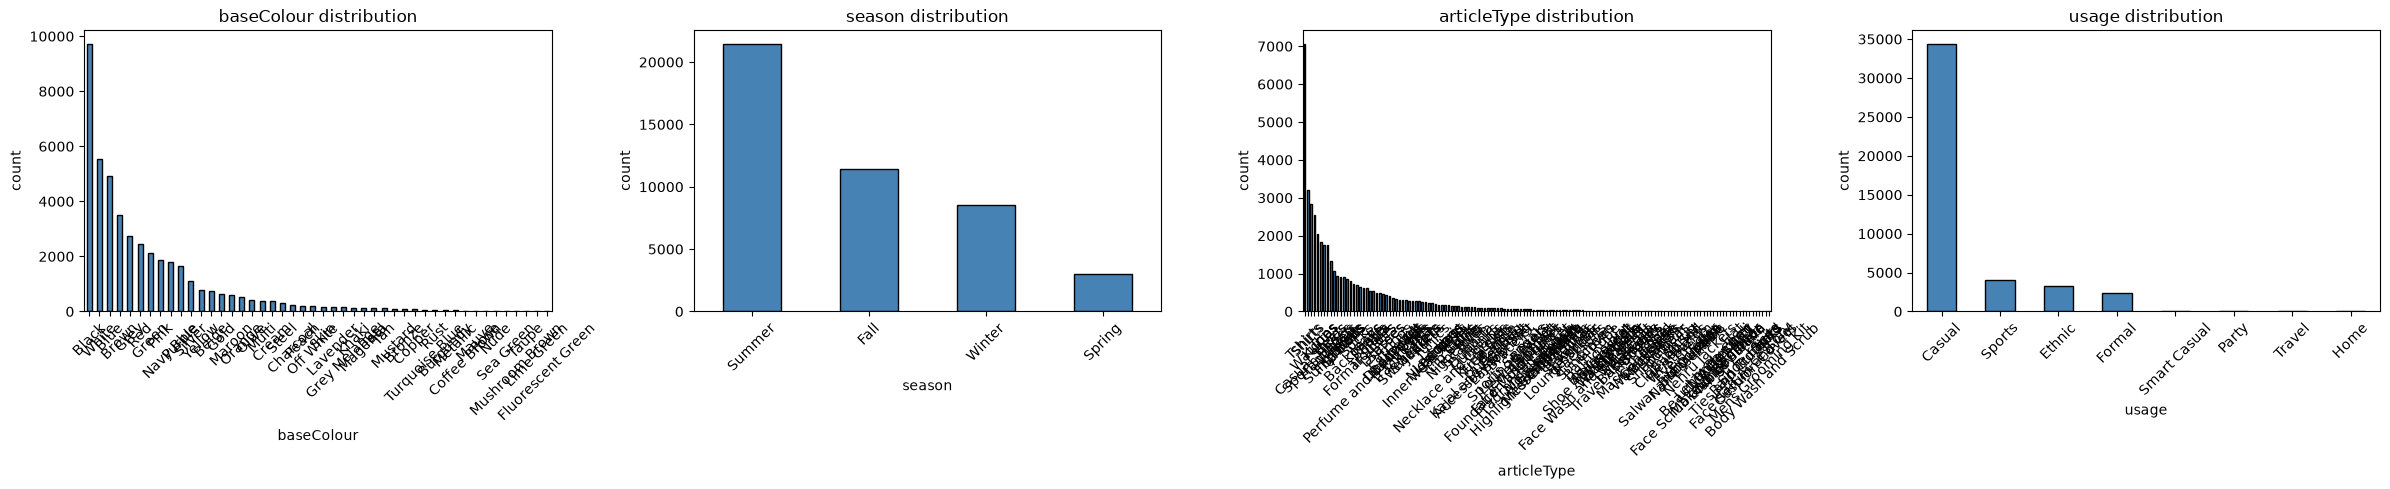

In [4]:
fig, axes = plt.subplots(1, len(available_labels), figsize=(6 * len(available_labels), 5))
if len(available_labels) == 1:
    axes = [axes]

for ax, col in zip(axes, available_labels):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Filter and Balance

In [5]:
df_balanced = filter_and_balance(df, available_labels, min_samples=100)
print(f'Rows after balancing: {len(df_balanced)}')
df_balanced.head()

  Dropped NaN rows: 44424 → 44079
  [baseColour] 29 classes, 41027 rows after rare-class removal
  [season] 4 classes, 41027 rows after rare-class removal
  [articleType] 52 classes, 41027 rows after rare-class removal
  [usage] 4 classes, 41027 rows after rare-class removal
  Downsampled on [articleType]: 101 samples per class → 5252 rows total
Rows after balancing: 5252


,id,gender,masterCategory,subCategory,baseColour,season,year,usage,productDisplayName
0,9523,Unisex,Accessories,Bags,Blue,Fall,2011.0,Casual,ADIDAS Unisex Bess Bp Blue Backpacks
1,8522,Unisex,Accessories,Bags,Black,Summer,2011.0,Casual,Nike Unisex Nike Black Backpacks
2,39876,Women,Accessories,Bags,Purple,Summer,2012.0,Casual,ADIDAS Women Purple Striped Backpack
3,38139,Unisex,Accessories,Bags,Blue,Spring,2013.0,Casual,Wildcraft Unisex Blue & Grey Forerunner Backpack
4,19314,Unisex,Accessories,Bags,Red,Fall,2011.0,Casual,Nike Unisex Graphic North Classic Red Backpack


## 5. Sample Image Grid

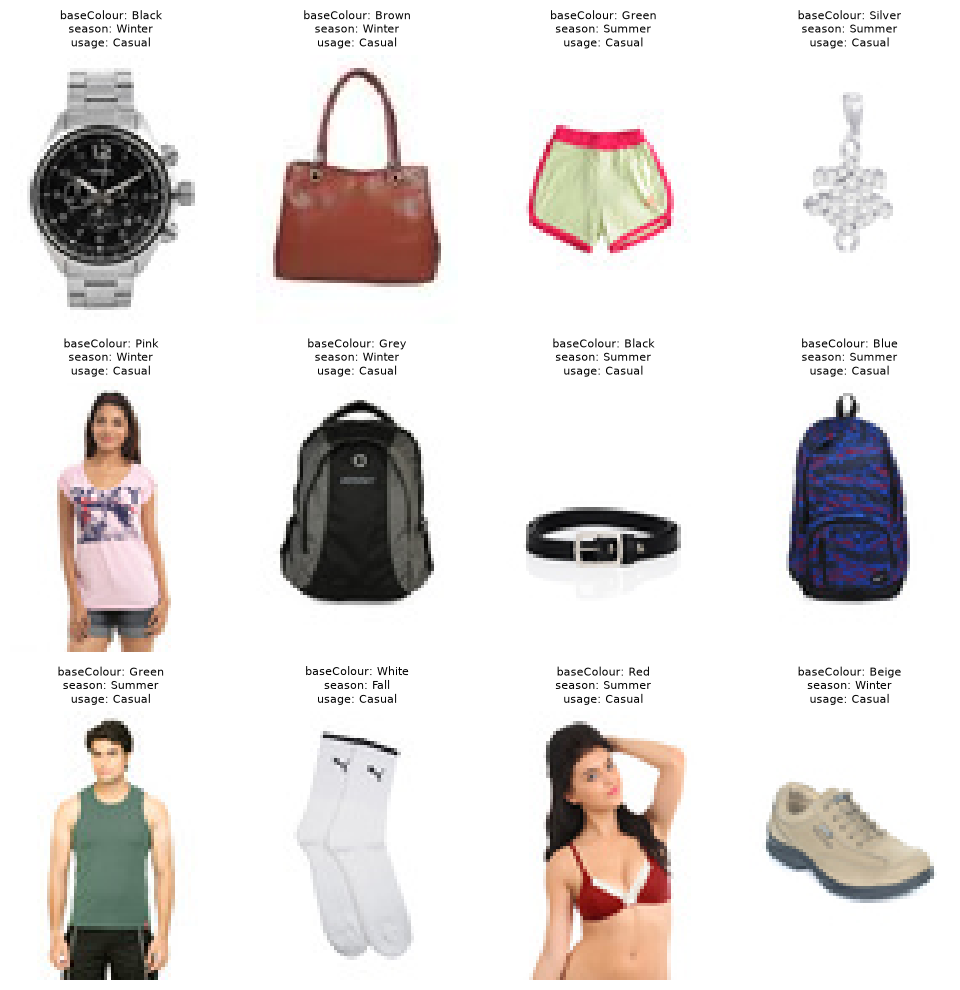

In [6]:
sample = df_balanced.sample(12, random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(10, 10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img_path = os.path.join(IMG_DIR, f"{row['id']}.jpg")
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
        label_text = '\n'.join(f'{col}: {row[col]}' for col in available_labels if col in row)
        ax.set_title(label_text, fontsize=8)
    except Exception as e:
        ax.set_title(f'Error: {e}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()